#  Voting Classifier — Ensemble Learning

---

## What is a Voting Classifier?

A **Voting Classifier** is an ensemble machine learning model that combines the predictions of **multiple individual classifiers** and outputs the final prediction based on a voting strategy.

The core idea is: *"The wisdom of the crowd beats any single expert."*

Instead of relying on one model, we train several models and let them **vote** on the final class label.

---

## Types of Voting

| Type | How it works | When to use |
|------|-------------|-------------|
| **Hard Voting** | Each classifier votes a class; majority wins | When models are equally trusted |
| **Soft Voting** | Average the predicted probabilities; pick highest | When models output probabilities |
| **Weighted Voting** | Like soft voting, but some models count more | When one model is known to be stronger |

---

## Dataset: Iris (Binary Subset)

We use the classic **Iris dataset**, but reduce it to a **binary classification** problem by keeping only two species (versicolor and virginica), using only `sepal_length` and `sepal_width` as features.

In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

### Load & Explore the Dataset

In [86]:
# Load the Iris dataset from seaborn
data = sns.load_dataset("iris")

print(f"Dataset shape : {data.shape}")
print(f"Species       : {data['species'].unique()}")
print(f"Missing values: {data.isnull().sum().sum()}\n")
data.head(2)

Dataset shape : (150, 5)
Species       : ['setosa' 'versicolor' 'virginica']
Missing values: 0



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa


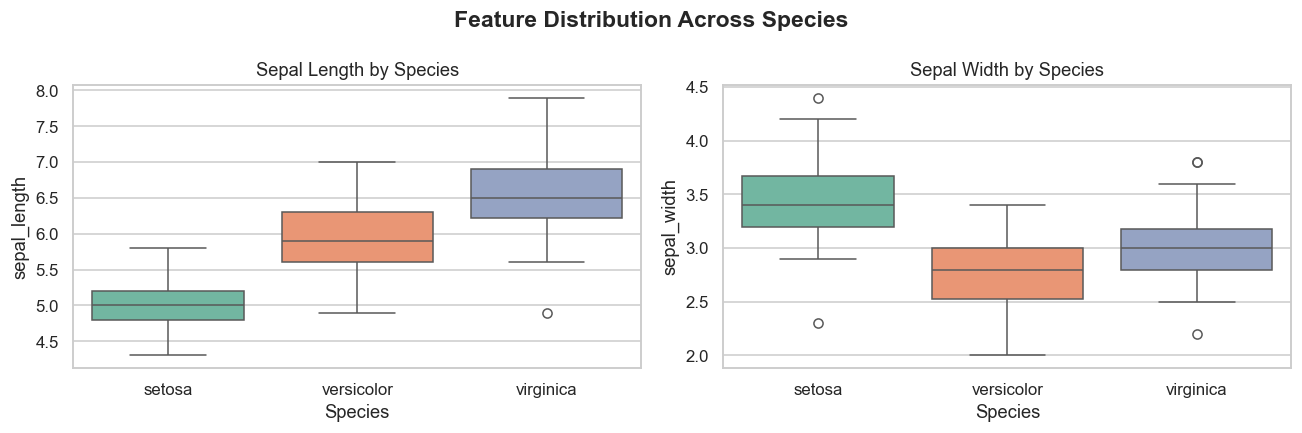

In [87]:
# ── EDA: Visualise the raw feature distributions per species 
plt.figure(figsize=(12,4))

# Sepal Length
plt.subplot(1,2,1)
sns.boxplot(data=data, x='species', y='sepal_length', palette='Set2')
plt.title('Sepal Length by Species')
plt.xlabel('Species')

# Sepal Width
plt.subplot(1,2,2)
sns.boxplot(data=data, x='species', y='sepal_width', palette='Set2')
plt.title('Sepal Width by Species')
plt.xlabel('Species')

plt.suptitle('Feature Distribution Across Species', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Label Encoding

> Machine learning models require **numeric** labels, not strings.  
> `LabelEncoder` maps each unique class string to an integer:
> - `setosa` → `0`
> - `versicolor` → `1`
> - `virginica` → `2`

In [89]:
encoder = LabelEncoder()
data['species'] = encoder.fit_transform(data['species'])

# Verify encoding mapping
print("Encoding map:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))
data.sample(3)

Encoding map: {'setosa': 0, 'versicolor': 1, 'virginica': 2}


,sepal_length,sepal_width,petal_length,petal_width,species
93,5.0,2.3,3.3,1.0,1
131,7.9,3.8,6.4,2.0,2
120,6.9,3.2,5.7,2.3,2


### Create Binary Dataset

We **drop the `setosa` class (label = 0)** and keep only two classes (`versicolor=1`, `virginica=2`).  
This simplifies the problem to binary classification and is a common technique to test model boundaries.

We also **keep only two features** (`sepal_length`, `sepal_width`) so we can easily visualise the decision boundary later.

In [91]:
# Keep only versicolor (1) and virginica (2), and two features
new_data = data[data['species'] != 0][['sepal_length', 'sepal_width', 'species']]

print(f"Filtered dataset shape : {new_data.shape}")
print(f"Class balance:\n{new_data['species'].value_counts()}")
new_data.head(2)

Filtered dataset shape : (100, 3)
Class balance:
species
1    50
2    50
Name: count, dtype: int64


,sepal_length,sepal_width,species
50,7.0,3.2,1
51,6.4,3.2,1


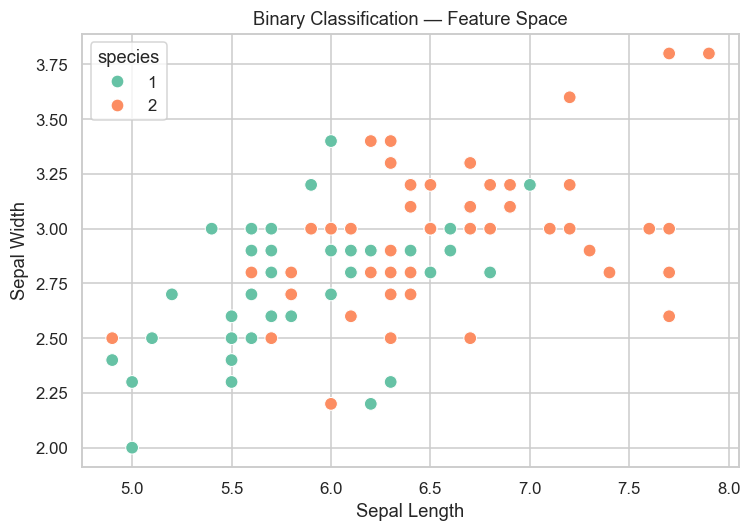

In [92]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=new_data,x='sepal_length',y='sepal_width',hue='species',palette=['#66c2a5', '#fc8d62'],s=70)
plt.title('Binary Classification — Feature Space')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.tight_layout()
plt.show()

### Train / Test Split

In [94]:
X = new_data.drop(columns=['species'])   # Features
y = new_data['species']                   # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 80
Test samples     : 20


### Define Individual Classifiers

We use **three diverse classifiers** as base learners. if all models make the *same* mistakes, voting won't help.

| Classifier | Strengths | Weaknesses |
|---|---|---|
| **Logistic Regression** | Fast, probabilistic, linear boundary | Struggles with non-linear data |
| **Decision Tree** | Non-linear, interpretable | Prone to overfitting |
| **SVC** | Robust margin-based, good for small data | Slow on large datasets, needs tuning |

> `probability=True` is set on SVC so it can output probability scores needed for **soft voting**.

In [96]:
clf1 = LogisticRegression(max_iter=200, random_state=42)   # Linear boundary
clf2 = DecisionTreeClassifier(random_state=42)             # Non-linear, tree-based
clf3 = SVC(probability=True, random_state=42)              # Margin-based, needs probability=True for soft voting

# Package into named estimator tuples (required by VotingClassifier)
estimators = [
    ('Logistic_Reg',  clf1),
    ('Decision_Tree', clf2),
    ('SVC',           clf3)
]

### Baseline — Individual Model Performance

Before combining models, we benchmark **each classifier alone** using 5-fold cross-validation.  
This tells us what improvement (if any) the ensemble provides.

In [98]:
individual_scores = {}

for name, clf in estimators:
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    individual_scores[name] = scores.mean()

    print(f"{name}: -> {scores.mean():.2%} (std: {scores.std():.3f})")

Logistic_Reg: -> 74.00% (std: 0.116)
Decision_Tree: -> 61.00% (std: 0.073)
SVC: -> 72.00% (std: 0.098)


### Hard Voting Classifier

In **hard voting**, each classifier casts a vote for its predicted class.  
The class with the **most votes wins**.

```
Sample X →  LR: class 1  |  DT: class 2  |  SVC: class 1
              Votes: {1: 2, 2: 1}  →  Prediction = 1
```

>Simple and robust. Does **not** require probability estimates.

In [100]:
vc_hard = VotingClassifier(estimators=estimators, voting='hard')

# Evaluate with 10-fold CV for a more stable estimate
hard_scores = cross_val_score(vc_hard, X, y, cv=10, scoring='accuracy')
hard_mean   = np.round(np.mean(hard_scores), 4)

print(f"Hard Voting — Mean CV Accuracy : {hard_mean:.2%}")
print(f"Hard Voting — Std              : {hard_scores.std():.3f}")

Hard Voting — Mean CV Accuracy : 75.00%
Hard Voting — Std              : 0.136


### Soft Voting Classifier

In **soft voting**, each classifier outputs a **probability for each class**.  
These probabilities are **averaged** across classifiers, and the class with the highest average probability is chosen.

```
Sample X →  LR: [0.7, 0.3]  |  DT: [0.4, 0.6]  |  SVC: [0.6, 0.4]
              Avg: [0.57, 0.43]  →  Prediction = class 1
```

>  Generally outperforms hard voting when models are well-calibrated.  
>  Requires all classifiers to support `predict_proba()` — hence `probability=True` on SVC.

In [102]:
vc_soft = VotingClassifier(estimators=estimators, voting='soft')

soft_scores = cross_val_score(vc_soft, X, y, cv=10, scoring='accuracy')
soft_mean   = np.round(np.mean(soft_scores), 4)

print(f"Soft Voting — Mean CV Accuracy : {soft_mean:.2%}")
print(f"Soft Voting — Std              : {soft_scores.std():.3f}")

Soft Voting — Mean CV Accuracy : 60.00%
Soft Voting — Std              : 0.184


### Weighted Soft Voting

**Weighted voting** allows you to give stronger models more influence.  
The weight vector `[i, j, k]` corresponds to `[LogisticRegression, DecisionTree, SVC]`.

We grid-search over weights `{1, 2, 3}` for each model and find the best combination.

> Higher weight → that model's probability is scaled up before averaging.

In [104]:
results = []   # store (i, j, k, accuracy) for plotting

for i in range(1, 4):
    for j in range(1, 4):
        for k in range(1, 4):
            vc_w = VotingClassifier(
                estimators=estimators,
                voting='soft',
                weights=[i, j, k]
            )
            scores = cross_val_score(vc_w, X, y, cv=10, scoring='accuracy')
            mean_acc = np.round(np.mean(scores), 4)
            results.append((i, j, k, mean_acc))
            print(f"  weights=[{i},{j},{k}]  →  Accuracy: {mean_acc:.2%}")

# Best combination
best = max(results, key=lambda x: x[3])
print(f"\n Best weights: LR={best[0]}, DT={best[1]}, SVC={best[2]}  →  Accuracy: {best[3]:.2%}")

  weights=[1,1,1]  →  Accuracy: 60.00%
  weights=[1,1,2]  →  Accuracy: 65.00%
  weights=[1,1,3]  →  Accuracy: 66.00%
  weights=[1,2,1]  →  Accuracy: 59.00%
  weights=[1,2,2]  →  Accuracy: 59.00%
  weights=[1,2,3]  →  Accuracy: 60.00%
  weights=[1,3,1]  →  Accuracy: 57.00%
  weights=[1,3,2]  →  Accuracy: 59.00%
  weights=[1,3,3]  →  Accuracy: 59.00%
  weights=[2,1,1]  →  Accuracy: 65.00%
  weights=[2,1,2]  →  Accuracy: 66.00%
  weights=[2,1,3]  →  Accuracy: 68.00%
  weights=[2,2,1]  →  Accuracy: 59.00%
  weights=[2,2,2]  →  Accuracy: 60.00%
  weights=[2,2,3]  →  Accuracy: 62.00%
  weights=[2,3,1]  →  Accuracy: 59.00%
  weights=[2,3,2]  →  Accuracy: 59.00%
  weights=[2,3,3]  →  Accuracy: 59.00%
  weights=[3,1,1]  →  Accuracy: 66.00%
  weights=[3,1,2]  →  Accuracy: 67.00%
  weights=[3,1,3]  →  Accuracy: 69.00%
  weights=[3,2,1]  →  Accuracy: 60.00%
  weights=[3,2,2]  →  Accuracy: 62.00%
  weights=[3,2,3]  →  Accuracy: 65.00%
  weights=[3,3,1]  →  Accuracy: 59.00%
  weights=[3,3,2]  →  Acc

### Performance Comparison — All Models

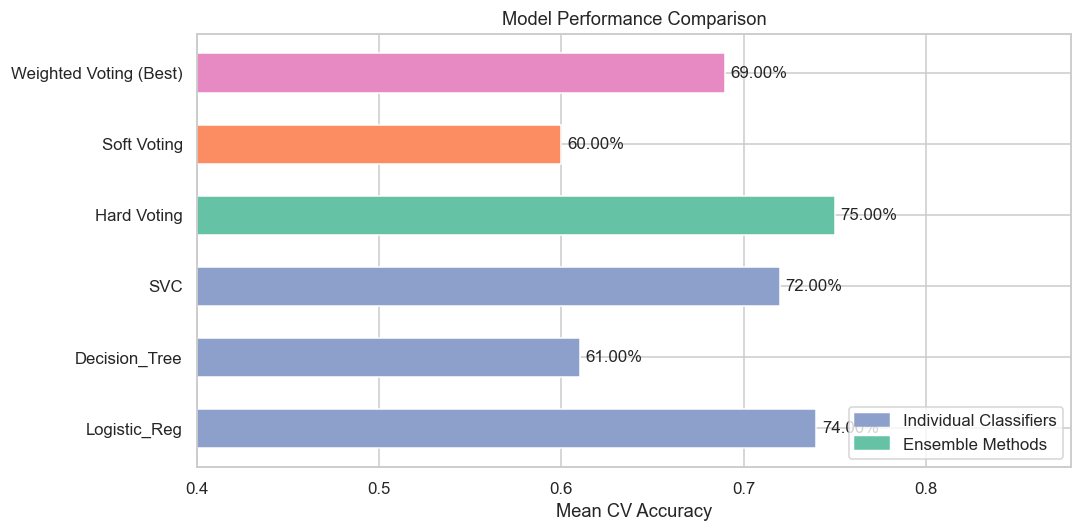

In [106]:
# Aggregate all scores
weighted_best = best[3]

model_names  = list(individual_scores.keys()) + ['Hard Voting', 'Soft Voting', 'Weighted Voting (Best)']
model_scores = list(individual_scores.values()) + [hard_mean, soft_mean, weighted_best]
colors_bar   = ['#8da0cb']*3 + ['#66c2a5', '#fc8d62', '#e78ac3']

plt.figure(figsize=(10,5))

bars = plt.barh(model_names, model_scores, color=colors_bar, edgecolor='white', height=0.55)

# Annotate bars
for bar, score in zip(bars, model_scores):
    plt.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
             f'{score:.2%}', va='center', fontsize=11)

plt.xlim(0.4, 0.88)
plt.xlabel('Mean CV Accuracy')
plt.title('Model Performance Comparison')

# Legend
import matplotlib.patches as mpatches
ind = mpatches.Patch(color='#8da0cb', label='Individual Classifiers')
ens = mpatches.Patch(color='#66c2a5', label='Ensemble Methods')
plt.legend(handles=[ind, ens], loc='lower right')

plt.tight_layout()
plt.show()

### Confusion Matrices — Hard vs Soft Voting

A confusion matrix shows how many predictions were **correct** vs **misclassified** per class.

- **Rows** = True labels  
- **Columns** = Predicted labels  
- **Diagonal** = Correct predictions 

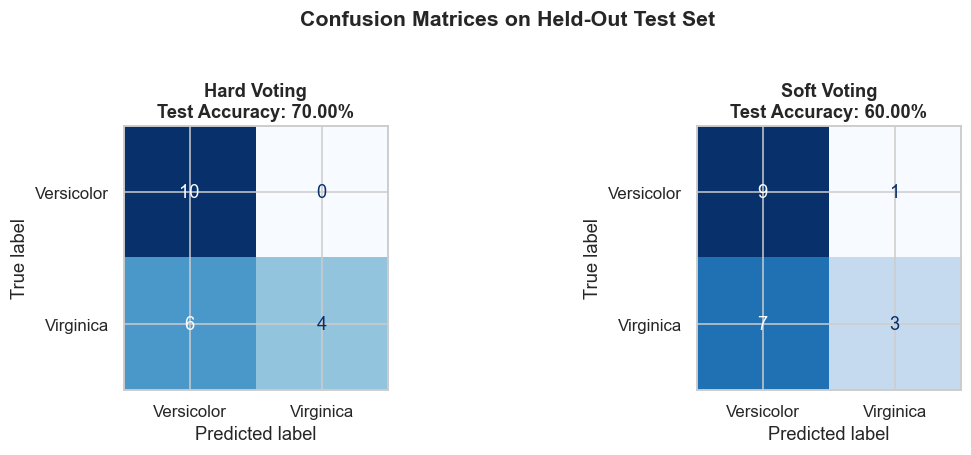

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (vc, title) in zip(axes, [(vc_hard, 'Hard Voting'), (vc_soft, 'Soft Voting')]):
    vc.fit(X_train, y_train)          # Train on the training split
    y_pred = vc.predict(X_test)       # Predict on the held-out test set
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Versicolor', 'Virginica']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'{title}\nTest Accuracy: {accuracy_score(y_test, y_pred):.2%}',
                 fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices on Held-Out Test Set', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### Summary 

| Concept | Insight |
|---|---|
| **Ensemble = diversity + combination** | Combining different models compensates for individual weaknesses |
| **Hard vs Soft Voting** | Soft voting usually wins when classifiers are well-calibrated |
| **Weighted Voting** | Assign more weight to your strongest model for a further boost |
| **Cross-validation** | Always use CV to get reliable accuracy estimates, not a single split |
| **Feature choice matters** | Using only 2 features makes the task harder — all models are modest here |
